<a href="https://colab.research.google.com/github/HalyshAnton/ITStep-AI/blob/superwised_learning/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Продаж велосипедів

<img src="https://user-images.githubusercontent.com/7065401/58563302-42466a80-8201-11e9-9948-b3e9f88a5662.jpg"
    style="width:400px; float: right; margin: 0 40px 40px 40px;"></img>


## Імпорт модулів

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Завантаження даних

In [2]:
sales = pd.read_csv(
    'https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module2/data/bike_sales.csv',
    index_col = "Unnamed: 0",
    parse_dates=['Date'])

sales.drop(columns=["Year"], inplace=True)


## Знайомство з даними

In [3]:
sales.head()

,Date,Day,Month,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [4]:
# назви стовпчиків до нижнього регістру
sales.columns = sales.columns.str.lower()

In [5]:
sales.shape

(113036, 17)

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113036 entries, 0 to 113035
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              113036 non-null  datetime64[ns]
 1   day               113036 non-null  int64         
 2   month             113036 non-null  object        
 3   customer_age      113036 non-null  int64         
 4   age_group         113036 non-null  object        
 5   customer_gender   113036 non-null  object        
 6   country           113036 non-null  object        
 7   state             113036 non-null  object        
 8   product_category  113036 non-null  object        
 9   sub_category      113036 non-null  object        
 10  product           113036 non-null  object        
 11  order_quantity    113036 non-null  int64         
 12  unit_cost         113036 non-null  int64         
 13  unit_price        113036 non-null  int64         
 14  profit   

## Аналіз числових ознак

### Основні статистичні характеристики

Середнє арифметичне(математичне сподівання) `mean`. Можна вважати типовим представником

In [7]:
sales['unit_cost'].mean()

np.float64(267.296365759581)

Якщо дані мають аномально великі чи малі значення(викиди) то кращим типовим представником буде медіана `median`. Це число яке є більшим рівно за половину даних.

**Стійкість характеристики до викидів називають робастністю (robust)**

In [8]:
median_cost = sales['unit_cost'].median()
median_cost

9.0

In [11]:
# частка даних менших за медіану
(sales['unit_cost'] < median_cost).mean()

np.float64(0.4776000566191302)

Також важливими є квантилі `quantile`: числа які більші рівно за певну частку даних. Найчастіше беруть перший(>25%) та третій(>75%)

In [20]:
q_3 = sales['unit_cost'].quantile(q=0.75)
q_3

np.float64(42.0)

In [19]:
# частка даних менших за медіану
(sales['unit_cost'] <= q_3).mean()

np.float64(0.317633320358116)

Окрім типового представника, важливим є те наскільки дані "сконцентровані" навколо нього. Для цього є дві характеристики: дисперсія `var` та стандартне відхилення `std`

<div>
<img src="https://homework.study.com/cimages/multimages/16/stdev1539666547228777994.png"
width="700"/>
</div>

In [ ]:
sales['unit_cost'].var()

In [23]:
sales['unit_cost'].std()

549.8354831077943

In [ ]:
print(f"корінь квадратний з дисперсії: {np.sqrt(sales['unit_cost'].var())}")
print(f"стандартне відхилення:         {sales['unit_cost'].std()}")

Усі ці характеристики можна отримати за допомогою методу `describe`

In [21]:
sales['unit_cost'].describe()

,unit_cost
count,113036.000000
mean,267.296366
std,549.835483
min,1.000000
25%,2.000000
50%,9.000000
75%,42.000000
max,2171.000000


In [22]:
sales.describe()

,date,day,customer_age,order_quantity,unit_cost,unit_price,profit,cost,revenue
count,113036,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,2014-11-23 12:14:55.063519232,15.665753,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
min,2011-01-01 00:00:00,1.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,2013-12-22 00:00:00,8.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,2014-06-27 00:00:00,16.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,2016-01-09 00:00:00,23.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,2016-07-31 00:00:00,31.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000
std,NaN,8.781567,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674


### Основні графіки

Гістограма показує кількість точок що належить конкретному проміжку. Має вигляд стовпчиків.

Text(0.5, 0, 'dollars')

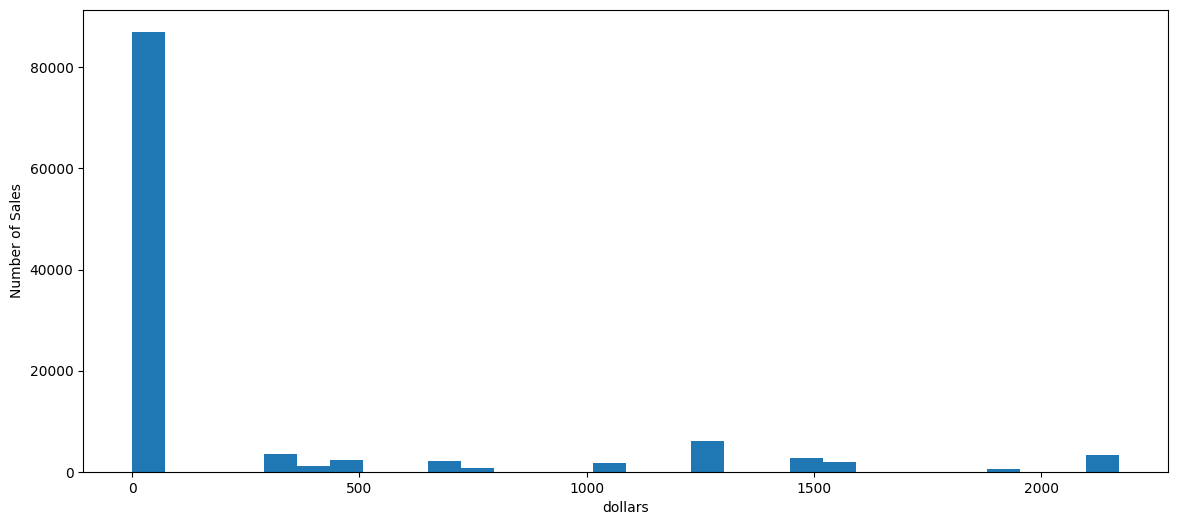

In [24]:
ax = sales['unit_cost'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('Number of Sales')
ax.set_xlabel('dollars')

Text(0.5, 0, 'Age')

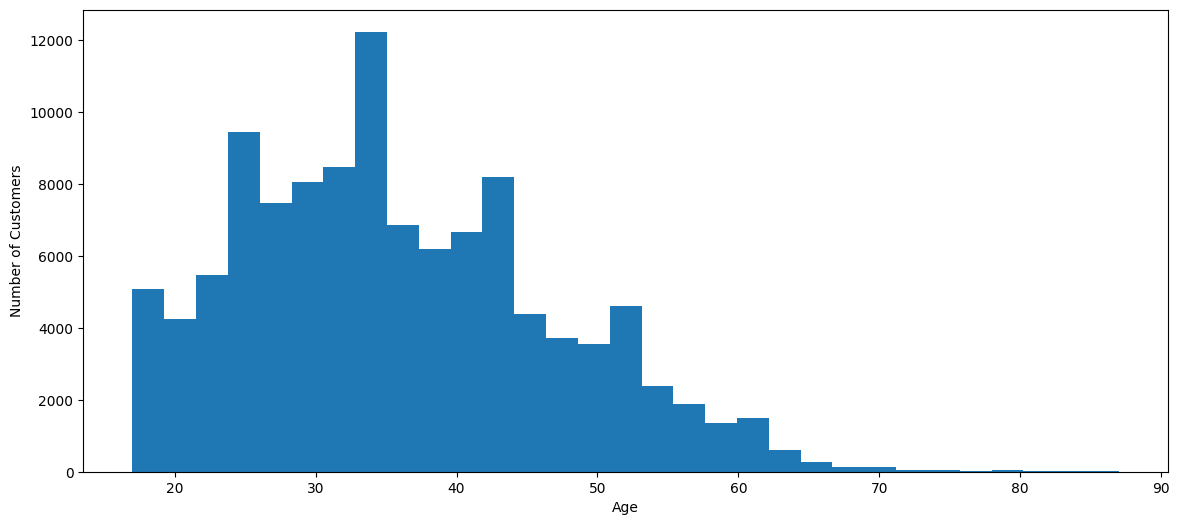

In [25]:
ax = sales['customer_age'].plot(kind='hist',    # тип діаграми hist
                                bins=31,        # кількість стовпчиків
                                figsize=(14,6)  # розмір зображення(в дюймах)
                               )


ax.set_ylabel('Number of Customers')
ax.set_xlabel('Age')

Вищенаведена гістограма є прикладом _поганих_ даних. Більшість алгоритмів ШІ вимагають щоб дані були _нормально розподілені_.

**Центральна гранична теорема:**
Сума деякої кількості незалежних і однаково розподілених випадкових величин із скінченною дисперсією буде прямувати до нормального розподілу із збільшенням кількості цих величин.

Через те, що на більшість числових величин впливає велика кількість _незалежних факторів_, умови теореми доволі часто виконуються.

В даному прикладі ми використовуємо згенеровані дані за допомогою `numpy`

In [ ]:
norm_data = np.random.normal(loc=0,      # середнє арифметичне
                             scale=30,   # стандартне відхилення
                             size=(50000,))

plt.hist(norm_data, bins=30)
plt.show()

Ящик з вусами `boxplot` показує взаємне розташування усіх квантилів(включно з медіаною), та дозволяє визначити викиди

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20201127012952/boxplot.png">

<Axes: >

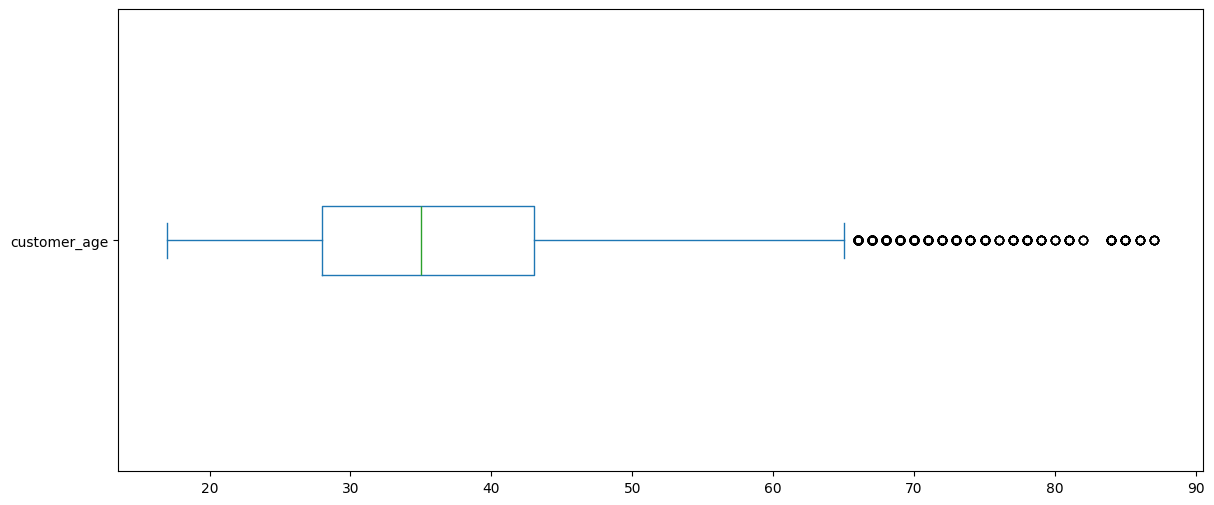

In [27]:
sales['customer_age'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

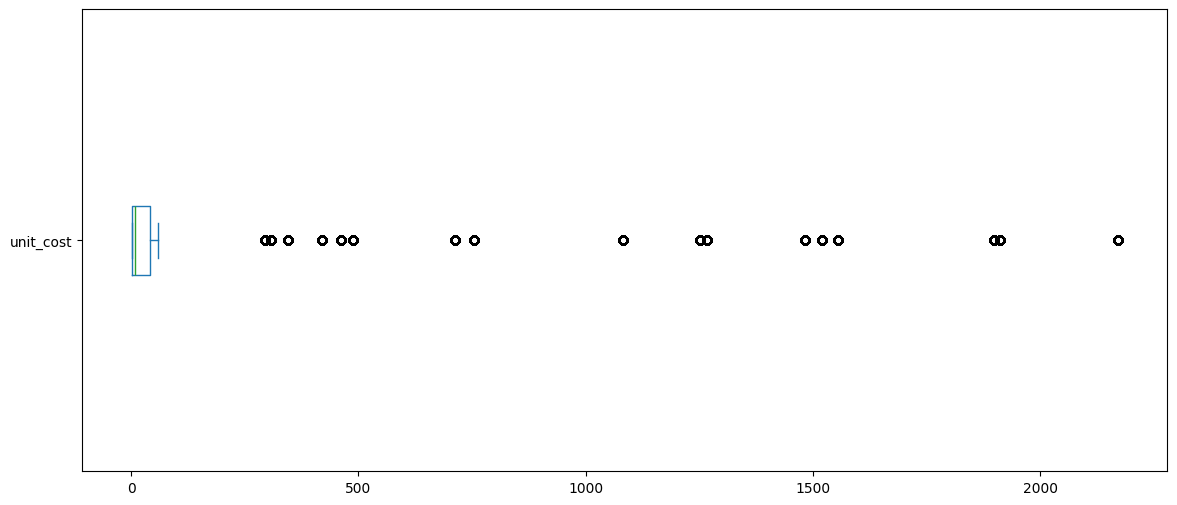

In [26]:
sales['unit_cost'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

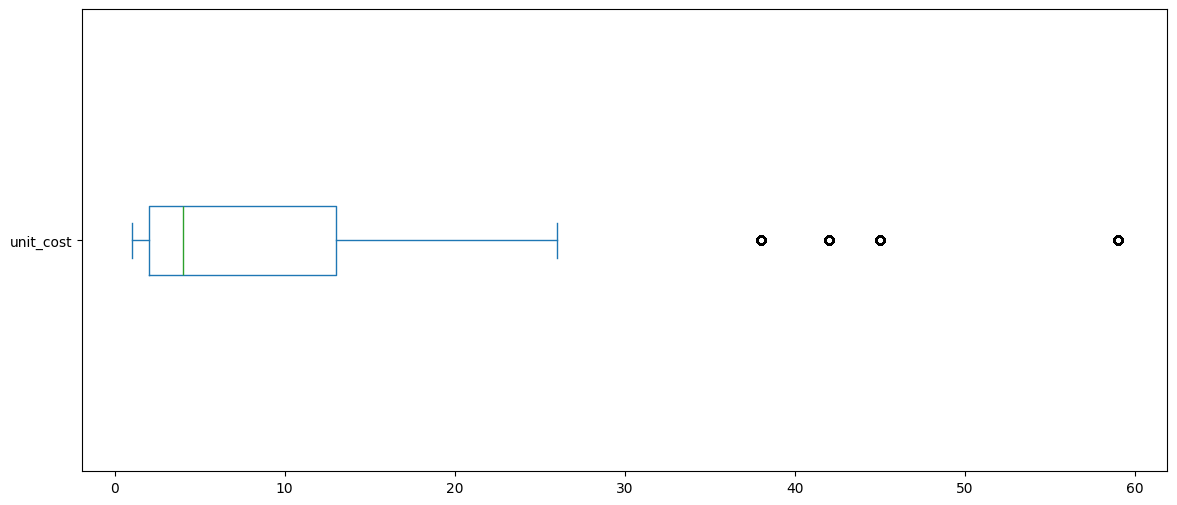

In [28]:
mask = sales["unit_cost"] < 100

sales[mask]['unit_cost'].plot(kind='box', vert=False, figsize=(14,6))

### Очищення від викидів

Існує бізліч алгоритмів для виявлення викидів(деякі з них вимагають умову нормальності даних), проте найбільш універсальним є квантильний аналіз:

1. Обчислюємо нижній `q1` та верхній `q3` квантилі
2. Очислюємо значення `IQR = q3 - q1`
3. Обчислюємо `lower = q1 - 1.5*IQR`
4. Обчислюємо `upper = q3 + 1.5*IQR`
5. Викидами вважаємо значення які `< lower` або `>upper`

Після очищення даних потрібно **обов'язково** перевірити їхню кількість

#### Варіант 1
Знаходими викиди для першого стовпчика, очищуємо і переходимо до наступного

In [29]:
def remove_outliers(df, column_name):
  column = df[column_name]

  q1 = column.quantile(q=0.25)
  q3 = column.quantile(q=0.75)

  iqr = q3 - q1

  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr

  mask = (column >= lower) & (column <= upper)

  return df[mask]


In [30]:
sales1 = sales.copy()

for column_name in sales1.columns:
  if sales1.dtypes[column_name] in ("object", "datetime64[ns]"):
    continue

  sales1 = remove_outliers(sales1, column_name)

sales1.shape


(67414, 17)

In [32]:
sales.shape

(113036, 17)

<Axes: >

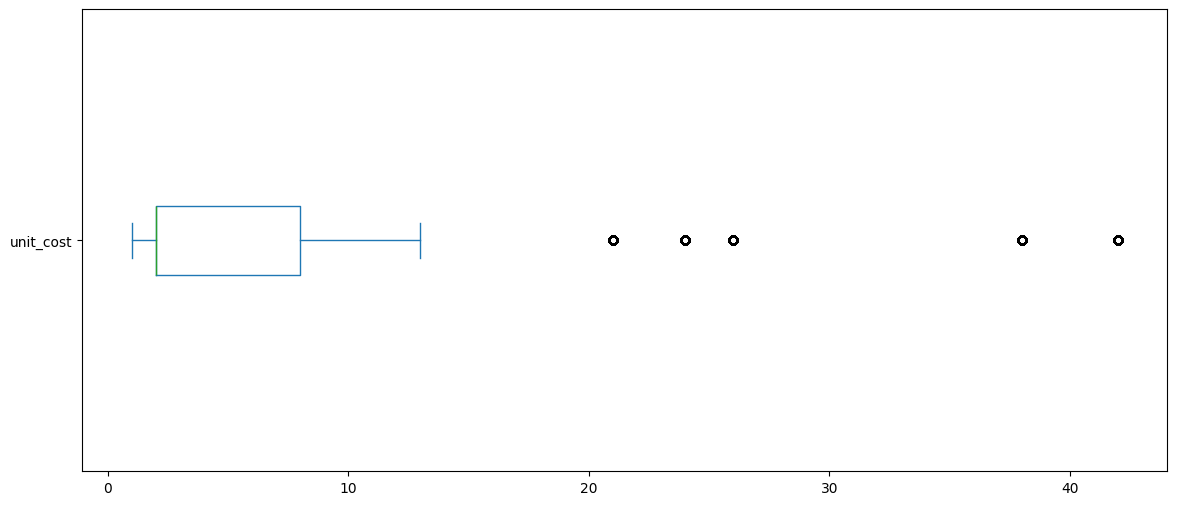

In [31]:
sales1['unit_cost'].plot(kind='box', vert=False, figsize=(14,6))

#### Варіант 2
Змінюємо коефіцієнт при `iqr` на 3

In [ ]:
def remove_outliers(df, column_name):
  column = df[column_name]

  q1 = column.quantile(q=0.25)
  q3 = column.quantile(q=0.75)

  iqr = q3 - q1

  lower = q1 - 3*iqr # замінити 1,5 на 3
  upper = q3 + 3*iqr

  mask = (column >= lower) & (column <= upper)

  return df[mask]

In [ ]:
sales2 = sales.copy()

for column_name in sales2.columns:
  if sales2.dtypes[column_name] in ("object", "datetime64[ns]"):
    continue

  sales2 = remove_outliers(sales1, column_name)


sales2.shape

#### Варіант 3
Спочатку знаходими викиди для всіх стовпчиків і лише потім очищуємо дані

In [ ]:
sales3 = sales.copy()

In [ ]:
sales_num = sales.select_dtypes(include='number')   # вибираємо стовпчики з числовими ознаками

sales_num

In [ ]:
q1 = sales_num.quantile(q=0.25)
q3 = sales_num.quantile(q=0.75)

iqr = q3 - q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

mask = (sales_num > lower) & (sales_num < upper)

mask = mask.all(axis=1)

# all -- все True
# any -- хоча б один True

# (row, col) -> (row)



In [ ]:
sales.head(5)

In [ ]:
   # включаємо лише ті рядки, де немає викиду по жодному стовпчику

cleaned_sales = sales3[mask]

In [ ]:
cleaned_sales.shape

### Ящик з вусами після очищення

In [ ]:
sales = cleaned_sales

In [ ]:
sales.columns = sales.columns.str.lower()

In [ ]:
sales['unit_cost'].plot(kind='box', vert=False, figsize=(14,6))

## Аналіз категоріальних ознак

In [ ]:
sales.head()

In [ ]:
len(sales)

In [ ]:
sales['age_group'].value_counts() / len(sales) * 100

In [ ]:
sales['age_group'].value_counts().plot(kind='pie')

In [ ]:
sales['age_group'].value_counts().plot(kind='bar')

In [ ]:
sales['age_group'].value_counts().plot(kind='pie', figsize=(6,6))

In [ ]:
ax = sales['age_group'].value_counts().plot(kind='bar', figsize=(14,6))
ax.set_ylabel('Number of Sales')

In [ ]:
sales.describe(include='object')



## Залежність між різними ознаками

### Кореляція
Коефіцієнт кореляції Пірсона вимірює лінійну залежність між двома наборами даних. Вимірюється в межех [-1, 1], де 1 - позитивна залежність, -1 - негативна, 0 - відсутність кореляції.

<img src="https://upload.wikimedia.org/wikipedia/commons/3/34/Correlation_coefficient.png">

In [ ]:
corr = sales.select_dtypes(include='number').corr(method='pearson')

corr

**Візуалізація**

In [ ]:
fig = plt.figure(figsize=(8, 8))
plt.matshow(corr, cmap='RdBu', fignum=False)

# підписи для рядків та стовпчиків матриці
plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr.columns)), corr.columns)

# кольорова панель
plt.colorbar()
plt.clim(-1, 1)

In [ ]:
sales.plot(kind='scatter', x='unit_cost', y='unit_price')

Для виявлення будь-якої зростаючої або спадаючої залежності є коефіцієнт кореляції Спірмена

In [ ]:
x = np.linspace(-100, 100, 100)
y = np.exp(x)

df = pd.DataFrame({'x': x,
                   'y': y})

print(f"pearson:  {df.corr(method='pearson').loc['x', 'y']}")
print()
print(f"spearman: {df.corr(method='spearman').loc['x', 'y']}")

In [ ]:
corr

In [ ]:
corr = sales.select_dtypes(include='number').corr(method='spearman')

fig = plt.figure(figsize=(8,8))
plt.matshow(corr, cmap='RdBu', fignum=False)

plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.clim(-1, 1)

### Точкові діаграми
Зображення двох характеристик як координат точок

In [ ]:
sales.head()

In [ ]:
sales.plot(kind='scatter', x='customer_age', y='profit')

In [ ]:
sales.plot(kind='scatter', x='revenue', y='profit', figsize=(6,6))

### Групові ящики з вусами
Зображають декілька ящиків з вусами одної(числової) характеристики, згрупованих за значенням іншої(категоріальної) характеристики

In [ ]:
sales

In [ ]:
sales.boxplot(column='customer_age', by='age_group')
plt.xticks(rotation=90)


In [ ]:
sales['country'].value_counts()

In [ ]:
sales.columns

In [ ]:
sales.groupby(by='sub_category')['profit'].median()

In [ ]:
# отриуємо лише катеоріальні стовпчики
cat_columns = sales.select_dtypes(include='object').columns

# групові ящики, для profit
for column_name in cat_columns:
    sales.boxplot(by=column_name, column='profit')
    plt.xticks(rotation=90)

# Попередня обробка даних

Попередня обробка даних - це важливий крок у конвеєрі науки про дані. Вона передбачає перетворення необроблених даних у чистий і придатний для використання формат, що робить їх готовими для аналізу або навчання моделей. Ось чому ви повинні виконувати попередню обробку даних і як ефективно працювати з різними типами даних.

## Чому потрібно попередньо обробляти дані

Дані часто надходять у різних форматах і містять неузгодженості, пропущені значення та шум. Попередня обробка допомагає

- **Покращити продуктивність моделі**: Чисті дані можуть призвести до кращої точності прогнозування.
- **Впоратися з відсутніми значеннями**: Вирішити, як обробити або врахувати відсутні дані.
- **Нормалізувати дані**: Переконайтеся, що числові характеристики мають узгоджену шкалу.
- **Перетворення категоріальних даних**: Перетворіть категоріальні змінні в числові представлення, зрозумілі моделям машинного навчання.
- **Зменшити перенавчання**: Спрощення моделі та зменшення шуму в даних.

## Категоріальна обробка

### OneHotEncoder

**Опис**: Ця методика перетворює категоріальні змінні у формат, який може бути наданий алгоритмам ML для кращого прогнозування.

- **Параметри**:
  - `categories`: Визначає категорії для кодування.
  - `drop`: Може відкинути одну з категорій, щоб уникнути мультиколінеарності.
  - `sparse`: Якщо встановлено в True, повертає розріджену матрицю; якщо False, повертає щільний масив.
  - `handle_unknown`: Визначає поведінку для невідомих категорій під час перетворення (варіанти: 'error', 'ignore').

<div>
<img src=https://miro.medium.com/v2/resize:fit:1400/1*ggtP4a5YaRx6l09KQaYOnw.png width='300%', height='300%'>
</div>

### OrdinalEncoder

**Опис**: Використовується для порядкових категорійних ознак, де категорії мають значущий порядок (наприклад, «низький», «середній», «високий»).

- **Параметри**:
  - `categories`: Визначає категорії та їх порядок.
  - `handle_unknown`: Визначає поведінку для невідомих категорій під час перетворення.

<div>
<img src=https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F11752239%2F325b419a72ffffdec197cf742a84bfd6%2FCategorical-data-encoding-label-encoding.webp?generation=1730000435665514&alt=media width='50%', height='50%'>
</div>

## Числова обробка

### StandardScaler

**Опис**: Стандартизує ознаки шляхом вилучення середнього значення та масштабування до одиничної дисперсії.

- Параметри**:
  - `copy`: Якщо значення True, робиться копія даних; якщо False, змінює вхідні дані.
  - `with_mean`: Якщо True, вирівнювання даних по центру перед масштабуванням.
  - `with_std`: Якщо True, масштабування до одиничної дисперсії.

<div>
<img src=https://miro.medium.com/v2/resize:fit:1400/1*mViMXFWPqg7Vg2WwjaoKVQ.png width='50%', height='50%'>
</div>

### PowerTransform

**Опис**: Застосовує степеневе перетворення, щоб зробити дані більш гауссівськими.

- **Параметри**:
  - `метод`: Може бути 'box-cox' (тільки для додатних даних) або 'yeo-johnson' (може обробляти від'ємні значення).
  - `standardize`: Якщо значення True, масштабує перетворені дані так, щоб вони мали нульове середнє та одиничну дисперсію.


<div>
<img src=https://media.geeksforgeeks.org/wp-content/uploads/20200531232546/output275.png width='70%', height='70%'>
</div>

### QuantileTransformer

**Опис**: Перетворює ознаки відповідно до рівномірного або нормального розподілу на основі квантилів даних.

- **Параметри**:
  - `n_quantiles`: Кількість квантилів для створення.
  - `output_distribution`: Може бути «uniform» або «normal».
  - `copy`: Якщо значення True, створюється копія даних.

<div>
<img src=https://www.tandfonline.com/cms/asset/b2af5d97-9625-45f7-9a34-cf0da9b2e600/cjas_a_1630372_f0003_oc.jpg width='50%' height='50%'>
</div>

### PolynomialFeatures

**Опис**: Генерує поліноміальні функції та функції взаємодії, що дозволяє створювати більш складні моделі.

- **Параметри**:
  - `degree`: Степінь поліноміальних функцій (наприклад, 2 для квадратичних).
  - `include_bias`: Якщо значення True, включає стовпчик одиницями.
  - `interaction_only`: Якщо значення True, створюються лише особливості взаємодії.

приклад перетворення двох стовпчиків (X, Y)

`interaction_only = True`  - $X, Y, XY$

`interaction_only = False` - $X, Y, X^2, Y^2, XY$

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

encoder = PolynomialFeatures(interaction_only=False, degree=2)
encoder.set_output(transform='pandas')

df = sales
df1 = df.dropna()
encoder.fit_transform(df1[['customer_age', 'order_quantity']])

### FuncTransformer

FuncTransformer - це універсальний інструмент у scikit-learn, який дозволяє вам застосовувати кастомні перетворення до ваших даних. Ви можете використовувати його для застосування таких функцій, як квадратний корінь, піднесення до квадрату або будь-яких інших математичних перетворень.

In [ ]:
from sklearn.preprocessing import FunctionTransformer


def transform(X):
    return np.hstack([np.sqrt(X), X, X**2])

def features_output(encoder, names):
    sqrt_names = [f'sqrt_{name}' for name in names]
    normal_names = [f'{name}' for name in names]
    squared_names = [f'{name}^2' for name in names]

    return sqrt_names + normal_names + squared_names


encoder = FunctionTransformer(func=transform,
                              feature_names_out=features_output)
encoder.set_output(transform='pandas')

encoder.fit_transform(df[['customer_age', 'order_quantity']])

## Заповнення пропусків

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

Для початку нам потрібно отримати назви стовпчиків з числовими та категоріальними ознаками, тому що для них обробка буде відрізнятися

In [ ]:
num_columns = df.select_dtypes(include='number').columns
cat_columns = df.select_dtypes(include='object').columns

In [ ]:
num_columns, cat_columns

Для числових ознак заповнюємо пропущені значення в кожному стовпчику його медіаною.

В параметр `steps` передаємо список кортежів з двлма значеннями: назва кроку та сам крок(об'єкт який здійснює обробку)

[(назва1, крок1),

 (назва2, крок2),

  ...
  
  ]

In [ ]:
num_transformer = Pipeline(
    [
        ('impute', SimpleImputer(strategy='median'))
    ]
)

num_transformer

Для категоріальних ознак застосовуємо наступну обробку:
* заповнюємо пропущені значення в кожному стовпчику значенням, яке найчастіше зустрічається
* застосовуємо кодування OneHotEncoder

In [ ]:
cat_transformer = Pipeline(
    [
        ('impute', SimpleImputer(strategy='constant',   # strategy='most_frequent'
                                 fill_value='UNKNOWN')),
         ('onehot', OneHotEncoder(sparse_output=False))
    ]
)

cat_transformer

Об'єднуємо обробку числових і категоріальних ознак в одну

В параметр `transformers` передаємо список кортежів з трьома значеннями: назва трансформера, сам трансформер, назви або індекси стовпчиків до яких це застосовувати

[(назва1, трансформер1, стовпчики1),

 (назва2, трансформер2, стовпчики2),

  ...
  
  ]

In [ ]:
preprocessor = ColumnTransformer(
    [
        ('num', num_transformer, num_columns),
        ('cat', cat_transformer, cat_columns)
    ]
)

preprocessor

In [ ]:
preprocessor.set_output(transform='pandas')
preprocessor.fit_transform(df)